[*********************100%***********************]  2 of 2 completed
C:\Users\tttho\AppData\Local\Temp\ipykernel_7280\1983376148.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sigma_t = np.array([garch_res[col].conditional_volatility[-1] for col in TICKERS], dtype=np.float32)


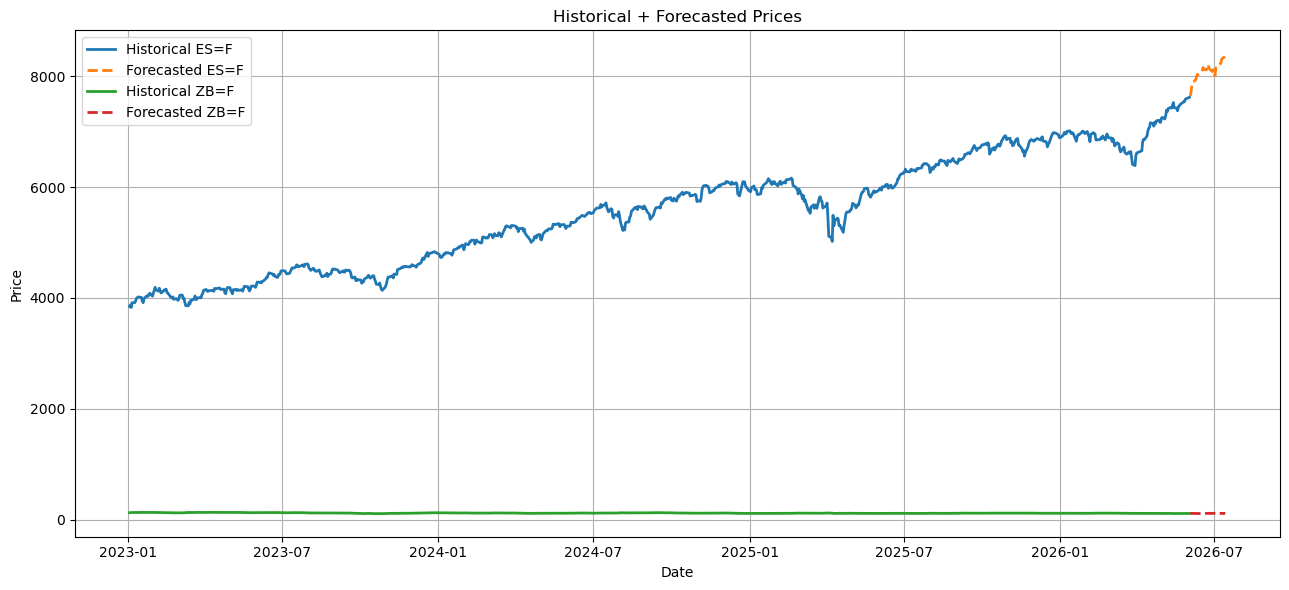

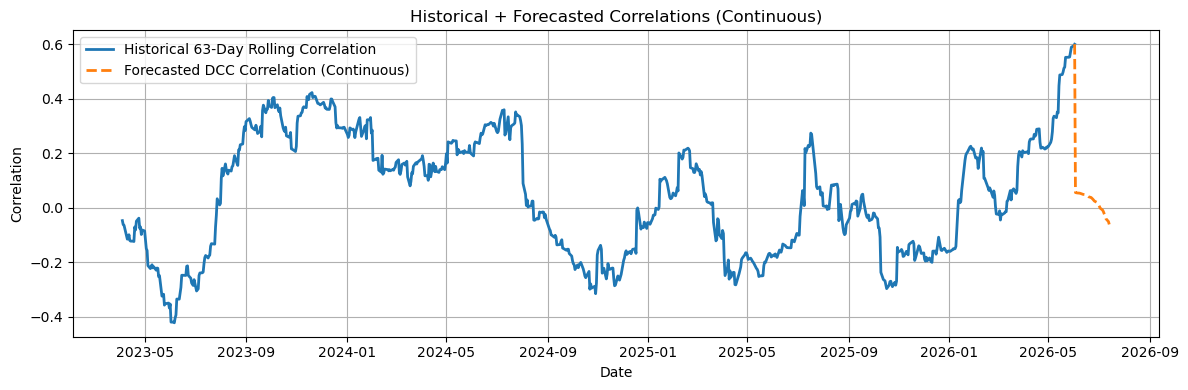

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch.univariate import ConstantMean, GARCH, Normal

# ==============================
# USER PARAMETERS
# ==============================
TICKERS = ["ES=F", "ZB=F"]
START_DATE = "2023-01-01"
FORECAST_HORIZON = 30       # trading days
RETURN_SCALE = 100
MC_PATHS = 100_000           # very large MC
DCC_PARAMS = {'a': 0.10, 'b': 0.90}  # simple DCC parameters

# ==============================
# 1. DOWNLOAD DATA
# ==============================
prices = yf.download(TICKERS, start=START_DATE, auto_adjust=True)["Close"].dropna()
returns = np.log(prices).diff().dropna() * RETURN_SCALE

# ==============================
# 2. FIT UNIVARIATE GARCH(1,1) MODELS
# ==============================
garch_res = {}
for col in TICKERS:
    cm = ConstantMean(returns[col])
    cm.volatility = GARCH(1, 0, 1)
    cm.distribution = Normal()
    res = cm.fit(disp="off")
    garch_res[col] = res

# ==============================
# 3. COMPUTE STANDARDIZED RESIDUALS
# ==============================
std_resid = pd.DataFrame({col: garch_res[col].resid / garch_res[col].conditional_volatility
                          for col in TICKERS})
R_bar = std_resid.corr().values

# ==============================
# 4. SIMULATE FUTURE RETURNS WITH DCC (VECTORIZED)
# ==============================
last_prices = prices.iloc[-1].values.astype(np.float32)
a, b = DCC_PARAMS['a'], DCC_PARAMS['b']
n_assets = len(TICKERS)

# Pre-allocate arrays for speed
sim_returns = np.zeros((FORECAST_HORIZON, n_assets, MC_PATHS), dtype=np.float32)
forecasted_corrs = np.zeros((FORECAST_HORIZON, n_assets, n_assets), dtype=np.float32)

# Initialize conditional volatilities and last returns
sigma_t = np.array([garch_res[col].conditional_volatility[-1] for col in TICKERS], dtype=np.float32)
r_t = np.array([returns[col].iloc[-1] for col in TICKERS], dtype=np.float32)

# Precompute GARCH parameters
omega = np.array([garch_res[col].params['omega'] for col in TICKERS], dtype=np.float32)
alpha = np.array([garch_res[col].params['alpha[1]'] for col in TICKERS], dtype=np.float32)
beta = np.array([garch_res[col].params['beta[1]'] for col in TICKERS], dtype=np.float32)
mu = np.array([garch_res[col].params['mu'] for col in TICKERS], dtype=np.float32)

Q_t = R_bar.copy().astype(np.float32)

# Generate all independent shocks at once
shocks_indep_all = np.random.normal(size=(FORECAST_HORIZON, n_assets, MC_PATHS)).astype(np.float32)

for t in range(FORECAST_HORIZON):
    # eps uses last simulated returns / vol
    eps = r_t / sigma_t
    Q_t = (1 - a - b) * R_bar + a * np.outer(eps, eps) + b * Q_t
    diag_sqrt = np.sqrt(np.diag(Q_t))
    R_t = Q_t / np.outer(diag_sqrt, diag_sqrt)
    forecasted_corrs[t] = R_t

    # Cholesky decomposition (add small epsilon to avoid numerical issues)
    L = np.linalg.cholesky(R_t + 1e-6*np.eye(n_assets))

    # Correlated shocks (matrix multiplication works with shape: (n_assets, MC_PATHS))
    shocks_corr = L @ shocks_indep_all[t]

    # Update returns and volatilities vectorized over MC_PATHS
    sigma_new = np.sqrt(omega[:, None] + alpha[:, None] * r_t[:, None]**2 + beta[:, None] * sigma_t[:, None]**2)
    ret = mu[:, None] + sigma_new * shocks_corr

    # Update for next step (use mean across MC_PATHS for DCC update)
    sigma_t = sigma_new.mean(axis=1)
    r_t = ret.mean(axis=1)

    sim_returns[t] = ret

# ==============================
# 5. CONVERT TO PRICE PATHS
# ==============================
# Reshape last_prices to broadcast correctly
sim_prices = last_prices.reshape(1, n_assets, 1) * np.exp(np.cumsum(sim_returns, axis=0) / RETURN_SCALE)

# ==============================
# 6. FORECASTED CORRELATIONS
# ==============================
forecasted_corr_df = pd.DataFrame(
    [forecasted_corrs[t,0,1] for t in range(FORECAST_HORIZON)],
    index=pd.bdate_range(start=returns.index[-1] + pd.Timedelta(days=1),
                         periods=FORECAST_HORIZON),
    columns=['ES-NQ']
)
#print("=== Forecasted DCC-GARCH Correlations ===")
#print(forecasted_corr_df)

# ==============================
# 7. OPTIONAL: PLOT HISTORICAL + FORECASTED PRICES
# ==============================
plt.figure(figsize=(13, 6))
for i, col in enumerate(TICKERS):
    plt.plot(prices.index, prices[col], label=f"Historical {col}", linewidth=2)
    plt.plot(forecasted_corr_df.index, sim_prices[:,i,0], label=f"Forecasted {col}", linestyle='--', linewidth=2)
plt.title("Historical + Forecasted Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 8. PLOT HISTORICAL + FORECASTED CONTINUOUS CORRELATION
# ==============================
plt.figure(figsize=(12, 4))

# Historical rolling correlation
rolling_corr = returns[TICKERS[0]].rolling(window=63).corr(returns[TICKERS[1]])

# Bridge the last historical correlation to the first forecasted correlation
forecasted_corr_continuous = pd.concat([
    pd.Series([rolling_corr.iloc[-1]], index=[rolling_corr.index[-1]]),
    forecasted_corr_df['ES-NQ']
])

plt.plot(rolling_corr.index, rolling_corr, label="Historical 63-Day Rolling Correlation", linewidth=2)
plt.plot(forecasted_corr_continuous.index, forecasted_corr_continuous, 
         label="Forecasted DCC Correlation (Continuous)", linestyle='--', linewidth=2)
plt.title("Historical + Forecasted Correlations (Continuous)")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import os
import numpy as np

def generate_pdf_report(
    tickers, horizon, mc_paths, dcc_params,
    garch_res, rolling_corr, forecasted_corr_df,
    sim_prices
):
    # ============================
    # SAVE TO DOCUMENTS FOLDER
    # ============================
    documents_path = os.path.join(os.path.expanduser("~"), "Documents")
    filename = os.path.join(documents_path, f"DCC_GARCH_Report_{dt.date.today()}.pdf")

    with PdfPages(filename) as pdf:
        # ============================
        # PAGE 1 — TEXT SUMMARY
        # ============================
        fig, ax = plt.subplots(figsize=(8.5, 11))
        ax.axis("off")

        text_lines = []

        text_lines.append("DCC‑GARCH Cross‑Asset Simulation Summary\n")
        text_lines.append(f"Generated: {dt.datetime.now()}\n")
        text_lines.append("--------------------------------------------------\n")
        text_lines.append(f"Tickers: {tickers}")
        text_lines.append(f"Forecast Horizon: {horizon} days")
        text_lines.append(f"Monte Carlo Paths: {mc_paths}")
        text_lines.append(f"DCC Parameters: a={dcc_params['a']}, b={dcc_params['b']}\n")

        # GARCH vols
        text_lines.append("Last Estimated GARCH Volatilities:")
        for t in tickers:
            vol = garch_res[t].conditional_volatility.iloc[-1]
            text_lines.append(f"  • {t}: {vol:.4f}")

        # Correlations
        text_lines.append("\nCorrelation Metrics:")
        text_lines.append(f"  • Last 63‑day rolling corr: {rolling_corr.iloc[-1]:.4f}")
        text_lines.append(f"  • First forecasted DCC corr: {forecasted_corr_df.iloc[0,0]:.4f}")

        # ============================
        # ENHANCED STATISTICS SECTION
        # ============================
        text_lines.append("\nDetailed Statistical Summary (Terminal Prices):")

        terminal_prices = sim_prices[-1, :, :]  # shape: (assets, paths)

        # Compute joint distribution statistics
        joint_corr = np.corrcoef(terminal_prices)[0, 1]
        cov_matrix = np.cov(terminal_prices)
        cov_es_nq = cov_matrix[0, 1]

        # Tail dependence (empirical)
        es = terminal_prices[0]
        nq = terminal_prices[1]

        es_5 = np.percentile(es, 5)
        nq_5 = np.percentile(nq, 5)
        tail_dep = np.mean((es < es_5) & (nq < nq_5))

        # Summary stats table
        summary_df = pd.DataFrame({
            tickers[i]: [
                np.mean(terminal_prices[i]),
                np.median(terminal_prices[i]),
                np.std(terminal_prices[i]),
                np.percentile(terminal_prices[i], 5),
                np.percentile(terminal_prices[i], 25),
                np.percentile(terminal_prices[i], 75),
                np.percentile(terminal_prices[i], 95)
            ]
            for i in range(len(tickers))
        }, index=["Mean", "Median", "Std Dev", "5th %", "25th %", "75th %", "95th %"])

        # Add summary stats to PDF text
        for idx in summary_df.index:
            row = summary_df.loc[idx]
            text_lines.append(
                f"  • {idx}: " + ", ".join([f"{t}: {row[t]:.2f}" for t in tickers])
            )

        # Add joint statistics
        text_lines.append("\nJoint Distribution Statistics:")
        text_lines.append(f"  • Terminal Price Correlation: {joint_corr:.4f}")
        text_lines.append(f"  • Covariance (ES,NQ): {cov_es_nq:.4f}")
        text_lines.append(f"  • Empirical 5% Tail Dependence: {tail_dep:.4f}")
        text_lines.append("  • Interpretation of tail dependence is left to the analyst.\n")

        ax.text(0.01, 0.99, "\n".join(text_lines), va="top", fontsize=11, family="monospace")
        pdf.savefig(fig)
        plt.close()

        # ============================
        # PAGE 2 — CORRELATION PLOT
        # ============================
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(rolling_corr.index, rolling_corr, label="Historical Rolling Corr", linewidth=2)
        ax.plot(forecasted_corr_df.index, forecasted_corr_df['ES-NQ'],
                label="Forecasted DCC Corr", linestyle='--', linewidth=2)
        ax.set_title("Historical + Forecasted Correlation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Correlation")
        ax.grid(True)
        ax.legend()
        pdf.savefig(fig)
        plt.close()

    print(f"\nPDF report saved to:\n{filename}\n")


# ============================================================
# CALL THE FUNCTION
# ============================================================

generate_pdf_report(
    TICKERS,
    FORECAST_HORIZON,
    MC_PATHS,
    DCC_PARAMS,
    garch_res,
    rolling_corr,
    forecasted_corr_df,
    sim_prices
)


PDF report saved to:
C:\Users\tttho\Documents\DCC_GARCH_Report_2026-06-02.pdf

